## Hands on CEBRA models

In [15]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cebra.datasets
from cebra import CEBRA
import os
import tempfile
from pathlib import Path

### CEBRA-Time (self-supervised embedding)

Set up a CEBRA model

In [16]:
# 1. Define a CEBRA model
cebra_model = CEBRA(
    model_architecture="offset10-model", # also 'offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse'
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.12, # factor to scale the similarity of the pairs
    max_iterations=5000, # default
    conditional='time', # for unsupervised. for supervised 'time_delta', or 'delta'
    output_dimension=3,
    distance='cosine', # also 'euclidean'
    device="cuda_if_available",
    verbose=True,
    time_offsets=10 # distance (in time) between positive pairs
)

In [17]:
# 2. Load the data
%mkdir data
hippocampus_pos = cebra.datasets.init('rat-hippocampus-single-achilles')

A subdirectory or file data already exists.


Plot the data

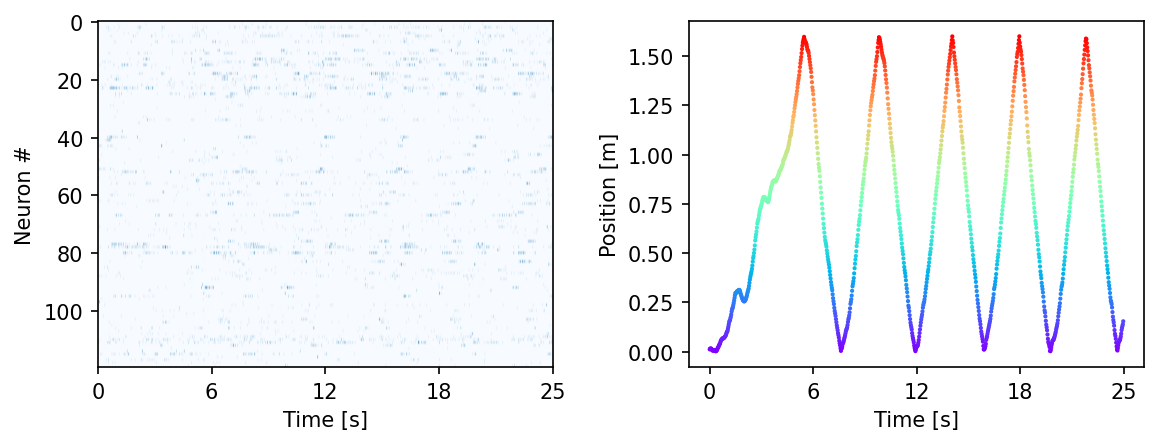

In [18]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos.neural.numpy()[:1000].T, aspect = 'auto', cmap = 'Blues')
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), hippocampus_pos.continuous_index[:1000, 0],
            c=hippocampus_pos.continuous_index[:1000, 0], cmap='rainbow', s=1)

plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

test: Train CEBRA-Time on the full data 

pos: -0.8508 neg:  6.3688 total:  5.5180 temperature:  1.1200: 100%|██████████| 5000/5000 [02:54<00:00, 28.69it/s]
100%|██████████| 500/500 [00:06<00:00, 73.79it/s]

 GoF in bits - full: 1.0385663912875314


<Figure size 500x500 with 0 Axes>

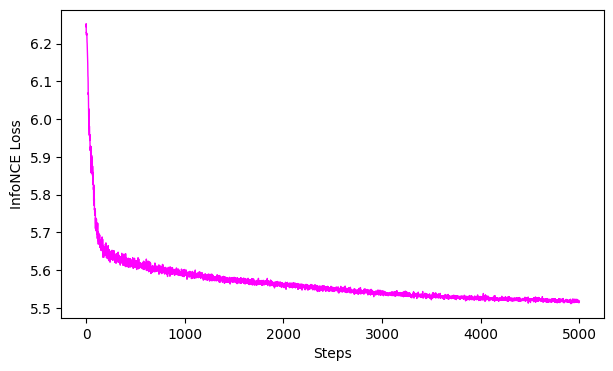

In [19]:
# training without labels on the full dataset on the above model 

# fit
cebra_time_full_model = cebra_model.fit(hippocampus_pos.neural)
# transform (get the embeddings)
cebra_time_full = cebra_model.transform(hippocampus_pos.neural)
# calculate GoF
gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_time_full_model, hippocampus_pos.neural)
print(" GoF in bits - full:", gof_full)
# plot embedding
fig = cebra.integrations.plotly.plot_embedding_interactive(cebra_time_full, embedding_labels=hippocampus_pos.continuous_index[:,0], title = "CEBRA-Time (full)", markersize=3, cmap = "rainbow")
fig.show()
# plot the loss curve
ax = cebra.plot_loss(cebra_time_full_model)

Create a Train/Validation Split

In [20]:
# 3. Split data and labels 

from sklearn.model_selection import train_test_split

split_idx = int(0.8 * len(hippocampus_pos.neural)) 

train_data = hippocampus_pos.neural[:split_idx]
valid_data = hippocampus_pos.neural[split_idx:]

train_continuous_label = hippocampus_pos.continuous_index.numpy()[:split_idx]
valid_continuous_label = hippocampus_pos.continuous_index.numpy()[split_idx:]

In [ ]:
# 4. Fit the train split model

cebra_train_model = cebra_model.fit(train_data)#, train_continuous_label)

In [ ]:
# 5. Save the model

tmp_file = Path(tempfile.gettempdir(), 'cebra.pt')
cebra_train_model.save(tmp_file)
#reload
cebra_train_model = cebra.CEBRA.load(tmp_file)

Compute the embedding 

In [ ]:
train_embedding = cebra_train_model.transform(train_data)
valid_embedding = cebra_train_model.transform(valid_data)

Evaluate the Model

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:09<00:00, 50.14it/s]


 GoF bits - train: 1.0413607984194195


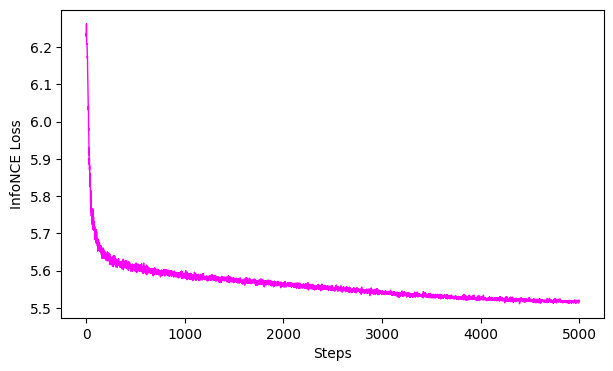

In [ ]:
# calculate the Goodness of Fit
gof_train = cebra.sklearn.metrics.goodness_of_fit_score(cebra_train_model, train_data)
print(" GoF bits - train:", gof_train)

# plot the loss curve
ax = cebra.plot_loss(cebra_train_model)

Visualize the embeddings

In [ ]:
import cebra.integrations.plotly

#train
fig = cebra.integrations.plotly.plot_embedding_interactive(train_embedding,
                                                           embedding_labels=train_continuous_label[:,0],
                                                           title = "CEBRA-Time Train",
                                                           markersize=3,
                                                           cmap = "rainbow")
fig.show()

#validation
fig = cebra.integrations.plotly.plot_embedding_interactive(valid_embedding,
                                                           embedding_labels=valid_continuous_label[:,0],
                                                           title = "CEBRA-Time-validation",
                                                           markersize=3,
                                                           cmap = "rainbow")
fig.show()

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

Validate consistency of embeddings

In [ ]:
# run train/val. 5-10 times 

X = 5  # number of training runs
model_paths = []  # store file paths

for i in range(X):
    print(f"Training 🦓CEBRA model {i+1}/{X}")

    # train and save model
    cebra_train_model = cebra_model.fit(train_data)
    tmp_file = Path(tempfile.gettempdir(), f'cebra_{i}.pt')
    cebra_train_model.save(tmp_file)
    model_paths.append(tmp_file)

# reload models and calculate embeddings
train_embeddings = []
valid_embeddings = []

for tmp_file in model_paths:
    cebra_train_model = cebra.CEBRA.load(tmp_file)
    train_embeddings.append(cebra_train_model.transform(train_data))
    valid_embeddings.append(cebra_train_model.transform(valid_data))

Training 🦓CEBRA model 1/5


  0%|          | 0/5000 [00:00<?, ?it/s]

pos: -0.8531 neg:  6.3691 total:  5.5160 temperature:  1.1200: 100%|██████████| 5000/5000 [03:31<00:00, 23.62it/s]


Training 🦓CEBRA model 2/5


pos: -0.8489 neg:  6.3706 total:  5.5217 temperature:  1.1200: 100%|██████████| 5000/5000 [03:33<00:00, 23.42it/s]


...

pos: -0.8358 neg:  6.3742 total:  5.5384 temperature:  1.1200: 100%|██████████| 5000/5000 [03:21<00:00, 24.77it/s]


Training 🦓CEBRA model 4/5


pos: -0.8566 neg:  6.3685 total:  5.5119 temperature:  1.1200: 100%|██████████| 5000/5000 [03:33<00:00, 23.37it/s]


Training 🦓CEBRA model 5/5


pos: -0.8505 neg:  6.3693 total:  5.5188 temperature:  1.1200: 100%|██████████| 5000/5000 [03:21<00:00, 24.85it/s]


<Axes: >

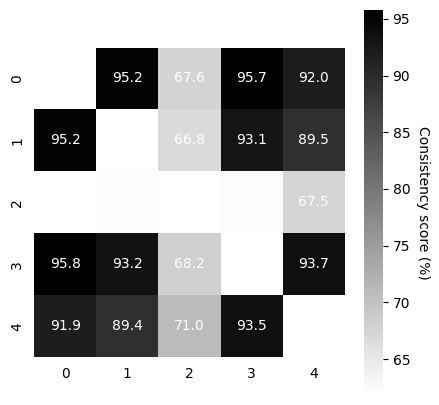

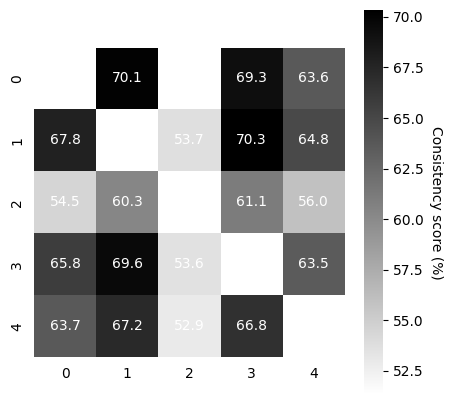

In [ ]:
# compute consistency across train/valid runs

# train embeddings 
scores, pairs, ids_runs = cebra.sklearn.metrics.consistency_score(
    embeddings=train_embeddings,
    between="runs"
)

cebra.plot_consistency(scores, pairs, ids_runs)

# valid embeddings 
scores, pairs, ids_runs = cebra.sklearn.metrics.consistency_score(
    embeddings=valid_embeddings,
    between="runs"
)

cebra.plot_consistency(scores, pairs, ids_runs)

Grid search 

In [ ]:
#%mkdir saved_models

params_grid = dict(
    output_dimension = [3, 6],
    time_offsets = [5, 10],
    model_architecture='offset10-model', 
    temperature_mode='constant',
    temperature=[0.1, 1.0],
    max_iterations=[5000],
    device='cuda_if_available',
    num_hidden_units = [32, 64],
    verbose = True)

datasets = {"dataset1": train_data}
# run the grid search
grid_search = cebra.grid_search.GridSearch()
grid_search.fit_models(datasets, params=params_grid, models_dir="saved_models")

In [ ]:
# Get the results
df_results = grid_search.get_df_results(models_dir="saved_models")

# Get the best model for a given dataset
best_model, best_model_name = grid_search.get_best_model(dataset_name="dataset1", models_dir="saved_models")
print("The best model is:", best_model_name)

In [ ]:
#load the top model 
model_path = Path("/content/saved_models") / f"{best_model_name}.pt"
top_model = cebra.CEBRA.load(model_path)

#transform:
top_train_embedding = top_model.transform(train_data)
top_valid_embedding = top_model.transform(valid_data)

# plot the loss curve
ax = cebra.plot_loss(top_model)


# plot embeddings
fig = cebra.integrations.plotly.plot_embedding_interactive(top_train_embedding,
                                                           embedding_labels=train_continuous_label[:,0],
                                                           title = "top model - train",
                                                           markersize=3,
                                                           cmap = "rainbow")
fig.show()

fig = cebra.integrations.plotly.plot_embedding_interactive(top_valid_embedding,
                                                           embedding_labels=valid_continuous_label[:,0],
                                                           title = "top model - validation",
                                                           markersize=3,
                                                           cmap = "rainbow")
fig.show()

### CEBRA-Behavior (using auxiliary labels supervised embedding)

In [22]:
# Define the model
cebra_behavior_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta', #using labels
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

pos: -0.9068 neg:  6.4116 total:  5.5048 temperature:  1.0000: 100%|██████████| 5000/5000 [05:24<00:00, 15.43it/s]
100%|██████████| 500/500 [00:23<00:00, 21.54it/s]

 GoF in bits - full: 1.0389887559125486


<Figure size 500x500 with 0 Axes>

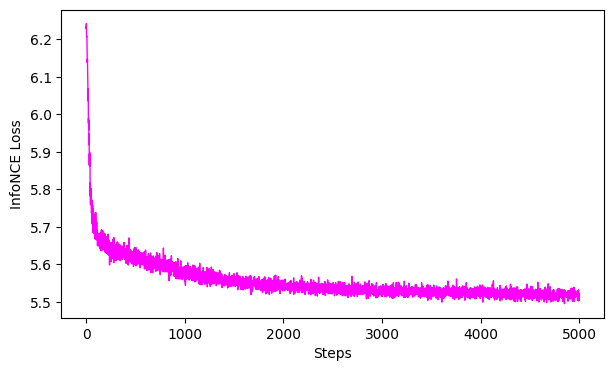

In [23]:
# fit
cebra_behavior_full_model = cebra_behavior_model.fit(hippocampus_pos.neural,hippocampus_pos.continuous_index.numpy())
# transform
cebra_behavior_full = cebra_behavior_full_model.transform(hippocampus_pos.neural)
# GoF
gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_behavior_full_model, hippocampus_pos.neural,hippocampus_pos.continuous_index.numpy())
print(" GoF in bits - full:", gof_full)
# plot embedding
fig = cebra.integrations.plotly.plot_embedding_interactive(cebra_behavior_full, embedding_labels=hippocampus_pos.continuous_index[:,0], title = "CEBRA-Behavior (full)", markersize=3, cmap = "rainbow")
fig.show()
# plot the loss curve
ax = cebra.plot_loss(cebra_behavior_full_model)

Test model consistency

In [ ]:
# run our train/val. 5-10 times to be sure they are consistent

X = 5  # Number of training runs
model_paths = []  # Store file paths

for i in range(X):
    print(f"Training 🦓CEBRA model {i+1}/{X}")

    # Train and save model
    cebra_behavior_train_model = cebra_behavior_model.fit(train_data,train_continuous_label)
    tmp_file2 = Path(tempfile.gettempdir(), f'cebra_behavior_{i}.pt')
    cebra_behavior_train_model.save(tmp_file2)
    model_paths.append(tmp_file2)


In [26]:
# Reload models and transform data
train_behavior_embeddings = []
valid_behavior_embeddings = []

for tmp_file2 in model_paths:
    cebra_behavior_train_model = cebra.CEBRA.load(tmp_file2, weights_only=False)
    train_behavior_embeddings.append(cebra_behavior_train_model.transform(train_data))
    valid_behavior_embeddings.append(cebra_behavior_train_model.transform(valid_data))

100%|██████████| 500/500 [00:19<00:00, 25.10it/s]

 GoF bits - train: 1.02456936448513


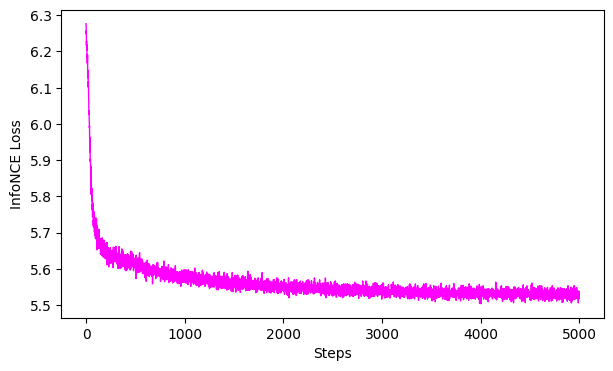

In [27]:
gof_train = cebra.sklearn.metrics.goodness_of_fit_score(cebra_behavior_train_model, train_data, train_continuous_label)
print(" GoF bits - train:", gof_train)

ax = cebra.plot_loss(cebra_behavior_train_model)

<Axes: >

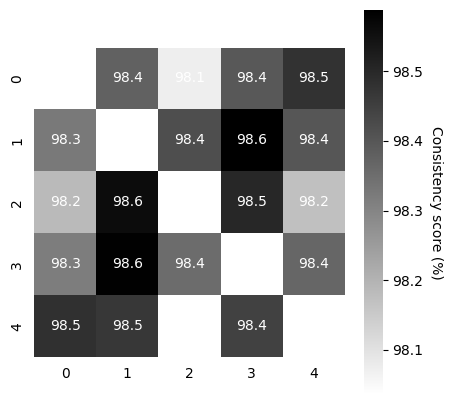

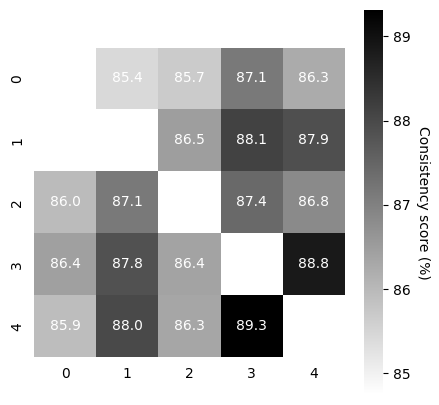

In [28]:
#train
scores, pairs, ids_runs = cebra.sklearn.metrics.consistency_score(
    embeddings=train_behavior_embeddings,
    between="runs"
)

cebra.plot_consistency(scores, pairs, ids_runs)

#validation
scores, pairs, ids_runs = cebra.sklearn.metrics.consistency_score(
    embeddings=valid_behavior_embeddings,
    between="runs"
)

cebra.plot_consistency(scores, pairs, ids_runs)

Shuffle controls

In [ ]:
'''
only when using labels. Important: the distribution of the labels shape the embedding. 
if labels are shuffled, it is not possible to fit them.
'''

In [29]:
# label Shuffle control model:
cebra_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

In [30]:
# shuffle the behavior variable and use it for training
shuffled_pos = np.random.permutation(hippocampus_pos.continuous_index[:,0])

pos: -0.6416 neg:  6.8262 total:  6.1846 temperature:  1.0000: 100%|██████████| 5000/5000 [04:58<00:00, 16.77it/s]
100%|██████████| 500/500 [00:20<00:00, 24.37it/s]

 GoF in bits - full: 0.006165611089084922


<Figure size 500x500 with 0 Axes>

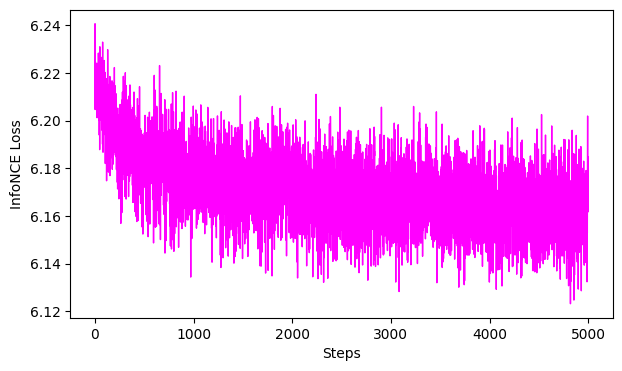

In [31]:
#fit, transform
cebra_shuffled_model.fit(hippocampus_pos.neural, shuffled_pos)
cebra_pos_shuffled = cebra_shuffled_model.transform(hippocampus_pos.neural)
# GoF
gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_shuffled_model, hippocampus_pos.neural,hippocampus_pos.continuous_index.numpy())
print(" GoF in bits - full:", gof_full)
# plot embedding
fig = cebra.integrations.plotly.plot_embedding_interactive(cebra_pos_shuffled, embedding_labels=hippocampus_pos.continuous_index[:,0], title = "CEBRA-Behavior (labels shuffled)", markersize=3, cmap = "rainbow")
fig.show()
# plot the loss curve
ax = cebra.plot_loss(cebra_shuffled_model)

In [ ]:
'''
Analysis: shuffles with the same parameters doesn't show any structure, GoF close to 0, 
and loss curve doesn't drop late in training. If this is the case, then we have good parameters.
(if loss curve still drops late in training, then we're overfitting).
'''